# FILL NULLS IN ENVIRONMENTAL DATA

In [1]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import joblib as joblib
from sklearn.impute import KNNImputer

In [3]:
from format import removeEmptyRows
from visualize import plotColsOnMap

The number of null values is almost negligible compared to real values. It only needs filling for Fe, solar data

In [4]:
env_df = pd.read_csv("../csv/features/env_data.csv") 
print(env_df.columns)
env_df.info(show_counts=True)

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)', 'O2', 'T', 'P', 'N', 'Fe',
       'solar'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265844 entries, 0 to 3265843
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   3265844 non-null  int64  
 1   LONGITUDE  3265844 non-null  int64  
 2   DEPTH (m)  3265844 non-null  int64  
 3   O2         3265844 non-null  float64
 4   T          3265844 non-null  float64
 5   P          3265844 non-null  float64
 6   N          3265844 non-null  float64
 7   Fe         3176482 non-null  float64
 8   solar      3265844 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 224.2 MB


In [5]:
data_cols = ['O2', 'T', 'N', 'P',"Fe", "solar"]
cor_cols = ['LATITUDE', 'LONGITUDE', "DEPTH (m)"]

In [6]:
env_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),O2,T,P,N,Fe,solar
count,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06,3.176482e+06,3.265844e+06
mean,-7.334634e+00,-1.126730e+01,2.493563e+01,2.597017e+02,1.468975e+01,6.790887e-01,7.416721e+00,2.362460e-01,1.536099e+02
std,4.327147e+01,1.096526e+02,1.580453e+01,5.771035e+01,1.079394e+01,6.166299e-01,9.369228e+00,2.613510e-01,2.743609e+01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,3.282310e-03,0.000000e+00,0.000000e+00,7.855326e+01
25%,-4.400000e+01,-1.140000e+02,1.000000e+01,2.071323e+02,3.931010e+00,1.720116e-01,2.911940e-01,4.650440e-02,1.308388e+02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.447867e+02,1.670499e+01,4.156240e-01,2.246612e+00,1.766478e-01,1.553868e+02
75%,2.400000e+01,8.400000e+01,4.000000e+01,3.127671e+02,2.514101e+01,1.130666e+00,1.271542e+01,3.299089e-01,1.787360e+02
max,9.000000e+01,1.780000e+02,5.000000e+01,5.041048e+02,3.029479e+01,2.688223e+00,4.080209e+01,3.285719e+00,1.952198e+02


This section can plot the data if needed but is commneted out to avoid too long execution

In [7]:
#plotColsOnMap(data_cols, env_df) can use the graph from previous file
#env_df = removeEmptyRows(data_cols, env_df) no need for this as clearly all rows have data

## Simple fill
The first strategy is to use mean value for each column to fill the missing data.

In [8]:
#we create a dictionary with mean value for each column name
means = dict(env_df.mean())

In [9]:
#we fill values and see the results in info
env_simple_fill = env_df.fillna(value=means)
env_simple_fill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265844 entries, 0 to 3265843
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   3265844 non-null  int64  
 1   LONGITUDE  3265844 non-null  int64  
 2   DEPTH (m)  3265844 non-null  int64  
 3   O2         3265844 non-null  float64
 4   T          3265844 non-null  float64
 5   P          3265844 non-null  float64
 6   N          3265844 non-null  float64
 7   Fe         3265844 non-null  float64
 8   solar      3265844 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 224.2 MB


In [ ]:
#I saved the results this can be useful for plotting them in a separate file
env_simple_fill.to_csv("./csv/filled/env_data_simple_fill.csv", index=False)

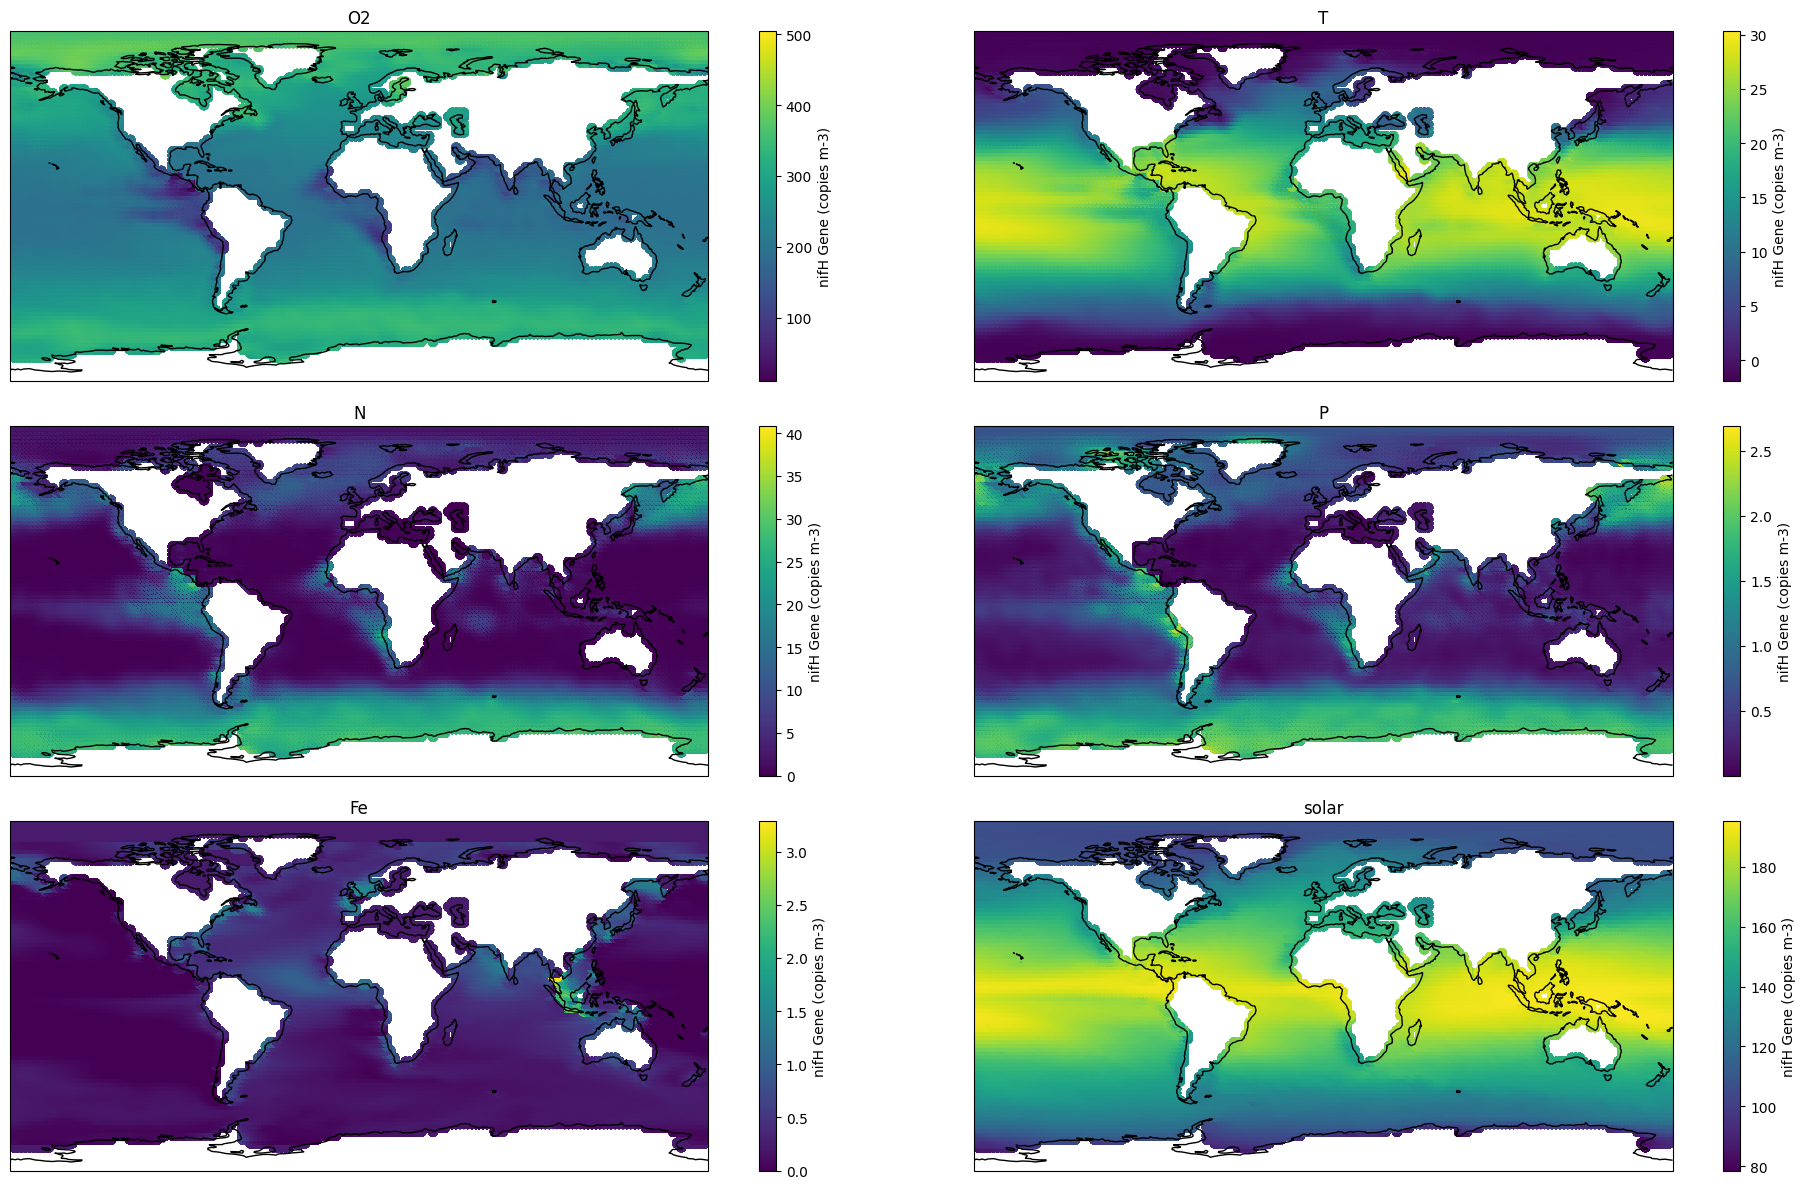

In [ ]:
#here the imputed values can be clearly seen on the map for the simple imputer (execution time: 3:20 min)
plotColsOnMap(data_cols, env_simple_fill, constant =1 )

## Complex fill
In this part I aimed to use coordinates in order to figure out what the best missing value might be.

### Latitude average
The first approach I wanted to try was Latitude based average. So, instead of taking the average of the entire planet, which can yield inaccurate results, we only use points on the same latitude. 

I think this can be quite good as the initial data clearly varies a lot based on latitude and thus, latitude is an important factor that should be accounted for when filling in the gaps.

In [12]:
avg_cols = []

for col in data_cols:
    avg_col = env_df.groupby('LATITUDE')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    avg_cols.append(avg_col)

env_lat_fill = pd.concat([env_df[cor_cols]]+avg_cols, axis=1)

env_lat_fill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265844 entries, 0 to 3265843
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   3265844 non-null  int64  
 1   LONGITUDE  3265844 non-null  int64  
 2   DEPTH (m)  3265844 non-null  int64  
 3   O2         3265844 non-null  float64
 4   T          3265844 non-null  float64
 5   N          3265844 non-null  float64
 6   P          3265844 non-null  float64
 7   Fe         3194498 non-null  float64
 8   solar      3265844 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 224.2 MB


#### Adding N:P and Fe nulls
Additional N:P feature to the dataset is added and the value for Fe is filled with average because we need no null values in the dataset.

In [13]:
# additional column is added
env_lat_fill["N:P"]=env_lat_fill["N"]/env_lat_fill["P"]
data_cols.append("N:P")

#we create a dictionary with mean value for each column name
means = dict(env_df.mean())

#we fill values and see the results in info
env_lat_fill.fillna(value=means, inplace=True)
env_lat_fill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265844 entries, 0 to 3265843
Data columns (total 10 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   3265844 non-null  int64  
 1   LONGITUDE  3265844 non-null  int64  
 2   DEPTH (m)  3265844 non-null  int64  
 3   O2         3265844 non-null  float64
 4   T          3265844 non-null  float64
 5   N          3265844 non-null  float64
 6   P          3265844 non-null  float64
 7   Fe         3265844 non-null  float64
 8   solar      3265844 non-null  float64
 9   N:P        3265844 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 249.2 MB


As we can see this method is not that computationally intensive, but manages to produce way better results overall.

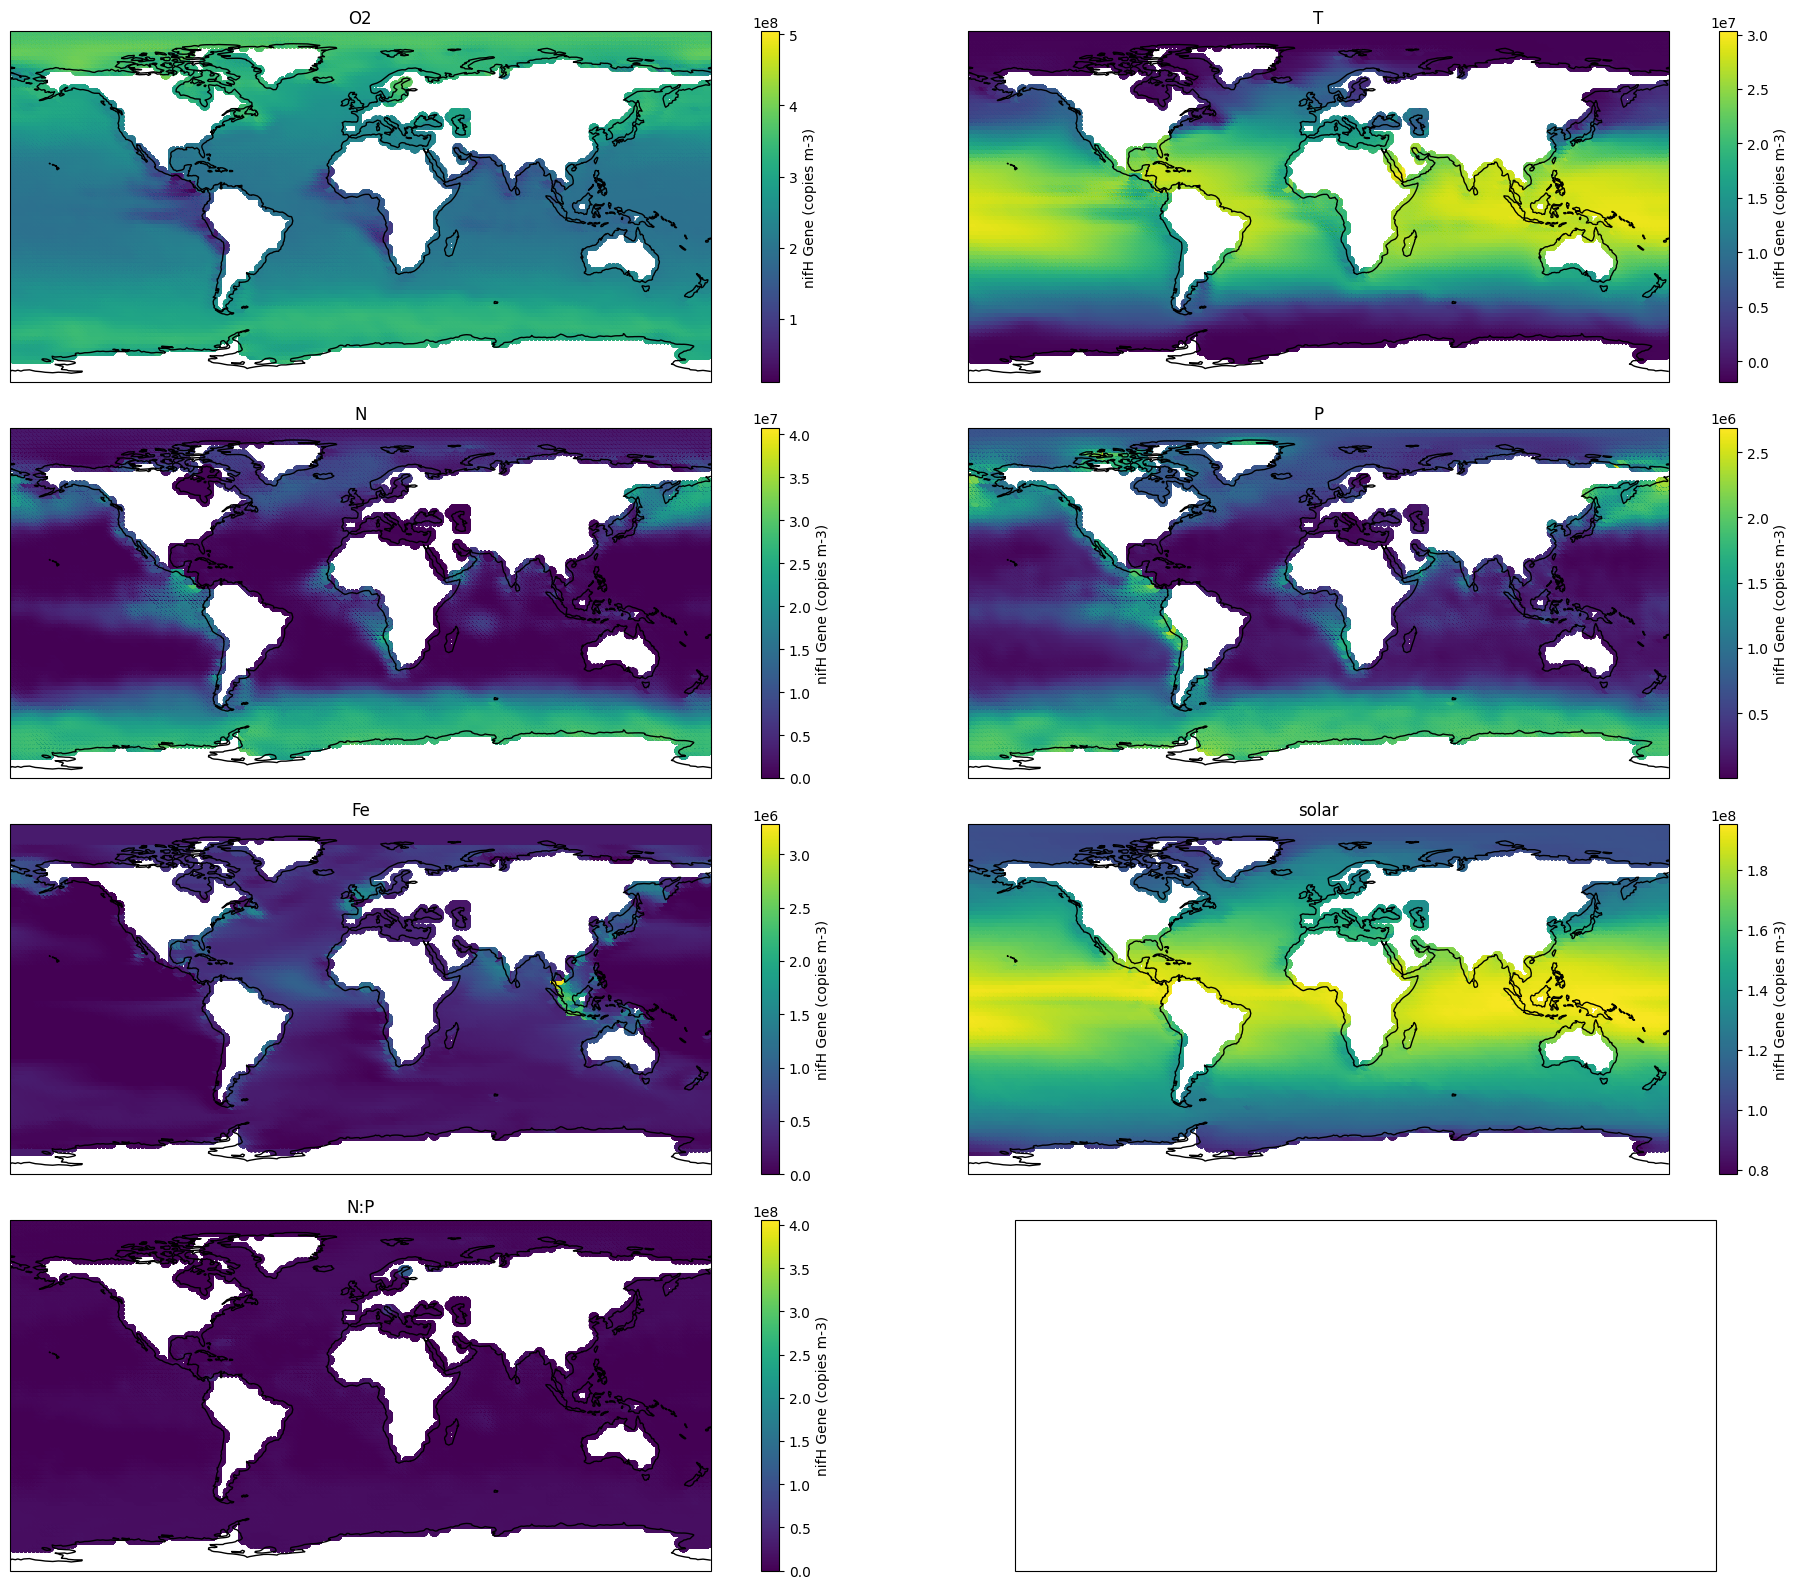

In [ ]:
# latitude fill based plot approximately 4 min to execute
plotColsOnMap(data_cols, env_lat_fill)

In [15]:
env_lat_fill.to_csv("../csv/filled/env_data_lat_fill.csv", index=False)

### KNN imputer
This is a more computationally intensive option, but it likely will produce overall more accurate results. On my laptop the cell below took more than 10 minutes to run compared to less than a second for the latitude based average.

However, I think the accuracy tradeof is worth it as it doesn't produce signigicantly better results overall and should only be used when excessive computational resource is available

In [16]:
# KNNImputer: fill missing using nearest geographic neighbors
'''
imputer = KNNImputer(n_neighbors=5, weights="distance")

env_knn = pd.DataFrame(imputer.fit_transform(env_df), columns=cor_cols+data_cols)

joblib.dump(imputer, "../model/imputer_knn")
'''

'\nimputer = KNNImputer(n_neighbors=5, weights="distance")\n\nenv_knn = pd.DataFrame(imputer.fit_transform(env_df), columns=cor_cols+data_cols)\n\njoblib.dump(imputer, "../model/imputer_knn")\n'

In [17]:
#plotColsOnMap(data_cols, env_knn)

In [18]:
#save the data
#env_knn.to_csv("../csv/filled/env_data_knn_fill.csv", index=False)

## Combining the dataframes into 1
In order to make it easier to analyze and work with it would make sense to not only store the datasets separately, but also in a combined file. This section is to be removed due to likely high computational resource and not neccesary as we only use one of the sets.

In [19]:
'''#these are lists of new labels for each column
data_cols_simple = [el+"_simple" for el in data_cols]
data_cols_lat = [el+"_lat" for el in data_cols]
data_cols_knn = [el+"_knn" for el in data_cols]

#we want to repeat the same action for each frame
new_names = [data_cols_simple, data_cols_lat, data_cols_knn]
frames = [env_simple_fill, env_lat_fill,env_knn]

#here we store the results
new_frames = []

#here we go through the lists
for frame, names in zip(frames, new_names):
    rename = dict(zip(data_cols, names))
    renamed_fr = frame.rename(columns=rename)
    new_frame = renamed_fr.set_index(cor_cols)
    new_frames.append(new_frame)'''

'#these are lists of new labels for each column\ndata_cols_simple = [el+"_simple" for el in data_cols]\ndata_cols_lat = [el+"_lat" for el in data_cols]\ndata_cols_knn = [el+"_knn" for el in data_cols]\n\n#we want to repeat the same action for each frame\nnew_names = [data_cols_simple, data_cols_lat, data_cols_knn]\nframes = [env_simple_fill, env_lat_fill,env_knn]\n\n#here we store the results\nnew_frames = []\n\n#here we go through the lists\nfor frame, names in zip(frames, new_names):\n    rename = dict(zip(data_cols, names))\n    renamed_fr = frame.rename(columns=rename)\n    new_frame = renamed_fr.set_index(cor_cols)\n    new_frames.append(new_frame)'

In [20]:
'''#we join the results
combined_df = pd.concat(new_frames, axis=1)
combined_df.head()'''

'#we join the results\ncombined_df = pd.concat(new_frames, axis=1)\ncombined_df.head()'

In [21]:
#combined_df.info()

In [22]:
#combined_dedub = combined_df.groupby(by=['LATITUDE', 'LONGITUDE']).mean().reset_index()
#combined_dedub.info()

In [23]:
#combined_dedub.to_csv("../csv/filled/env_data_all_fill.csv", index=False)